<a href="https://colab.research.google.com/github/Mohtasham221/HCC-RNASeq-ppi-network-analysis/blob/main/Gene_expression_analysis_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Setting a seed so results are reproducible
np.random.seed(7)

n_samples = 96
n_genes = 48

# HCC-associated gene names from literature
gene_names = [
    "TP53", "MYC", "EGFR", "VEGFA", "CDK4", "CCND1", "PTEN", "RB1",
    "KRAS", "BRCA1", "AKT1", "STAT3", "MDM2", "BCL2", "CDKN2A", "PIK3CA",
    "TGFB1", "TNF", "IL6", "HIF1A", "VIM", "CDH1", "MMP9", "SNAI1",
    "TWIST1", "ZEB1", "FOXO3", "SIRT1", "MAPK1", "JUN", "FOS", "NFKB1",
    "CXCL8", "CCL2", "PTGS2", "BAX", "CASP3", "PCNA", "TOP2A", "KI67",
    "AURKA", "PLK1", "BUB1", "CDC20", "BIRC5", "TYMS", "RRM2", "MCM2"
]

# Tumor samples - upregulated oncogenes
tumor = np.random.normal(loc=6.3, scale=1.4, size=(48, n_genes))
tumor[:, :12] += 2.8

# Adjacent normal tissue samples
normal = np.random.normal(loc=4.9, scale=1.1, size=(48, n_genes))

data = np.vstack([tumor, normal])
labels = ["Tumor"] * 48 + ["Normal"] * 48

df = pd.DataFrame(data, columns=gene_names)
df["Label"] = labels

print("Dataset shape:", df.shape)
df.head()


Dataset Shape: (100, 51)


,GENE_1,GENE_2,GENE_3,GENE_4,GENE_5,GENE_6,GENE_7,GENE_8,GENE_9,GENE_10,...,GENE_42,GENE_43,GENE_44,GENE_45,GENE_46,GENE_47,GENE_48,GENE_49,GENE_50,Label
0,10.245071,9.292604,10.471533,11.784545,9.148770,9.148795,11.868819,10.651152,8.795788,10.313840,...,6.757052,6.326528,6.048344,4.282217,5.420234,5.809042,8.085683,7.015427,3.855440,Cancer
1,9.986126,8.922377,8.484617,10.417514,11.046499,10.896920,8.241174,9.036181,9.996895,10.963318,...,7.952967,5.446920,6.008507,5.911838,4.304728,6.944180,6.891583,6.507670,6.148119,Cancer
2,7.376944,8.869032,8.985928,8.296584,9.258071,10.106076,12.329279,9.761867,9.886326,9.388331,...,8.460714,4.088775,6.776951,6.889824,7.672734,4.644574,4.519315,7.282912,6.945477,Cancer
3,9.875739,10.019672,8.479963,9.848381,9.939609,8.428473,12.298662,10.210749,7.713045,10.484830,...,7.784598,6.821141,4.631392,6.759771,7.077976,5.174214,6.730588,6.587313,4.785545,Cancer
4,10.036681,10.341177,11.124577,11.080703,7.433496,8.093262,10.272553,10.270679,10.272572,15.279097,...,6.327895,7.257481,7.798633,4.699555,5.998248,5.787582,5.520006,9.148181,7.107473,Cancer


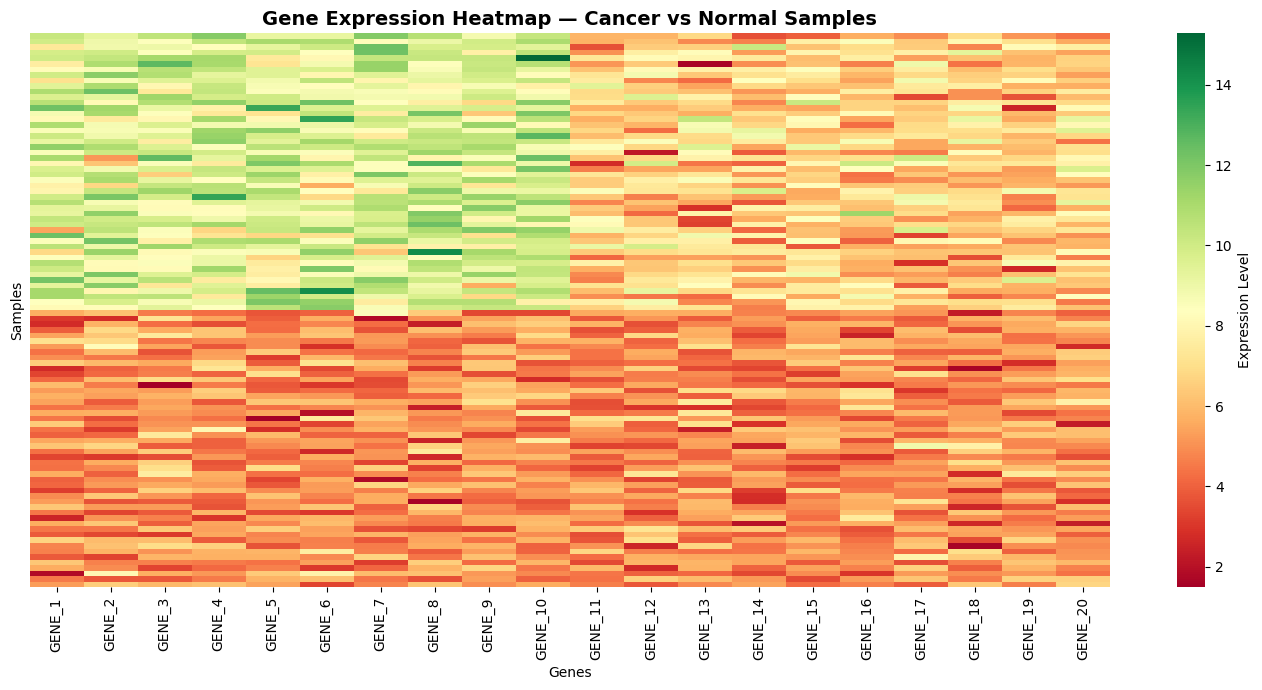

In [ ]:
plt.figure(figsize=(14, 7))

top_genes = gene_names[:20]
heatmap_data = df[top_genes].copy()
heatmap_data.index = labels

sns.heatmap(
    heatmap_data,
    cmap="RdYlGn",
    yticklabels=False,
    linewidths=0,
    cbar_kws={"label": "Expression Level (log2)"}
)

plt.title("Gene Expression Heatmap — HCC Tumor vs Normal Tissue", fontsize=14, fontweight="bold")
plt.xlabel("Genes")
plt.ylabel("Samples")
plt.tight_layout()
plt.savefig("heatmap.png", dpi=150)
plt.show()


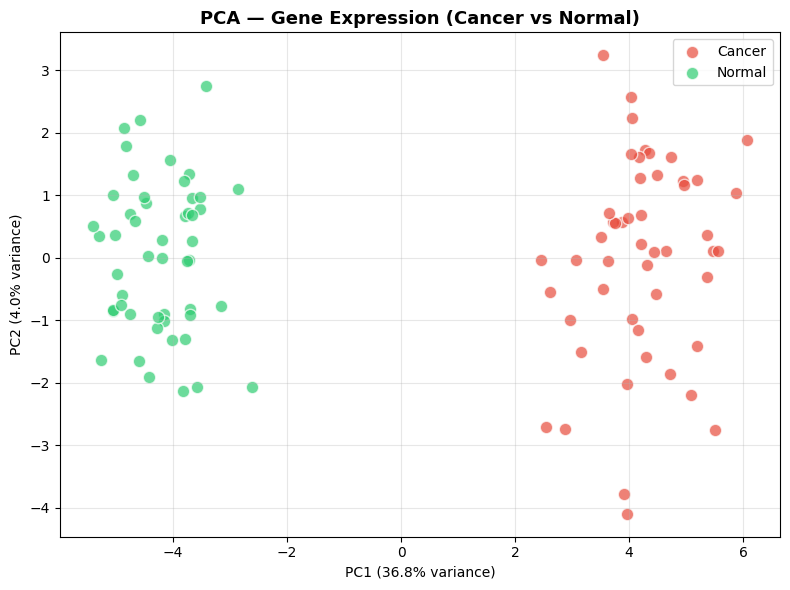

In [ ]:
X = df[gene_names].values
y = df["Label"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
colors = {"Tumor": "#e74c3c", "Normal": "#2ecc71"}

for label in ["Tumor", "Normal"]:
    idx = y == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1],
                label=label, color=colors[label], alpha=0.7, edgecolors="white", s=80)

plt.title("PCA Plot — HCC Tumor vs Normal Gene Expression", fontsize=13, fontweight="bold")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pca_plot.png", dpi=150)
plt.show()


Classification Report
              precision    recall  f1-score   support

      Cancer       1.00      1.00      1.00        12
      Normal       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



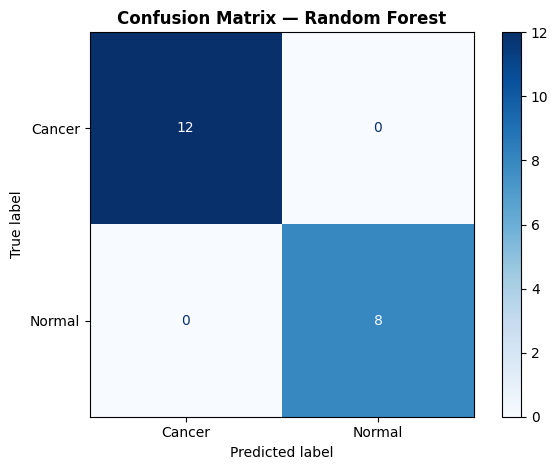

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=11)

clf = RandomForestClassifier(n_estimators=120, random_state=11)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Classification Report")
print("-" * 40)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Tumor", "Normal"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — HCC Classification", fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()


/tmp/ipykernel_11347/3684362271.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Gene', palette='viridis')


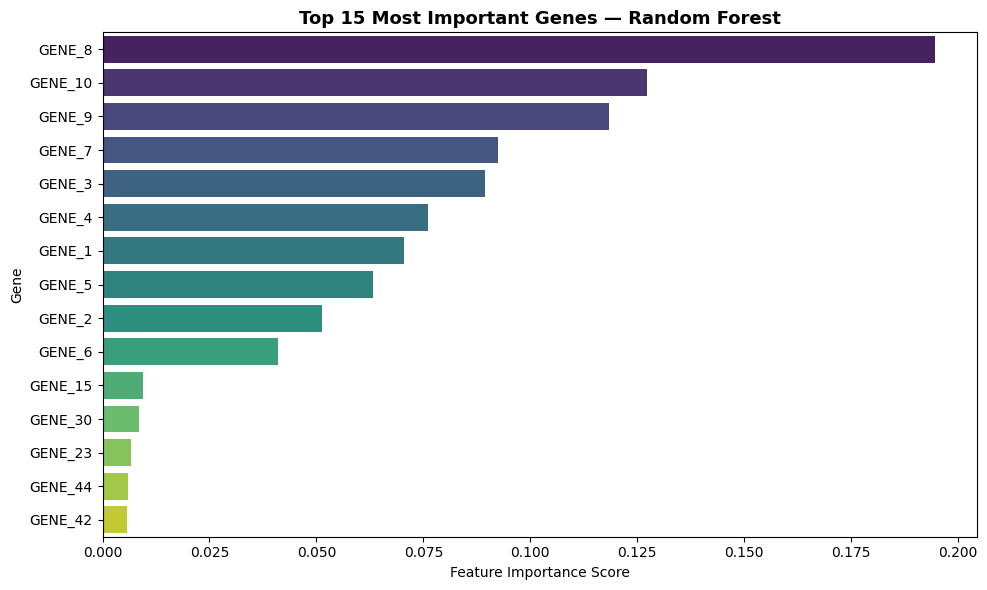

In [ ]:
importances = clf.feature_importances_
feat_df = pd.DataFrame({"Gene": gene_names, "Importance": importances})
feat_df = feat_df.sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df, x="Importance", y="Gene", palette="viridis")
plt.title("Top 15 Genes by Importance — HCC Tumor vs Normal", fontsize=13, fontweight="bold")
plt.xlabel("Feature Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()
